# Results vs. stratification metrics — does skill structure predict the AIP benefit?

Joins per-task outcomes from the four v0.3a3-era runs (cohorts **A/B/C** + **eval-3med**) with the
structural metrics in `skill-metrics.csv`, and asks: **where does converting a human skill to AIP
help, and does any stratification axis predict it?**

Outcome columns (per task, mean over 5 trials):
- `human_r` — mean reward, human-curated skill
- `aip_r` — mean reward, aip-from-curated skill
- `delta` = `aip_r − human_r` — the paired conversion effect (**primary DV**)
- `headroom` = `1 − human_r` — the max possible positive Δ (see the headroom section)

> ⚠️ **Exploratory only.** 27 tasks, and ~half are ties (Δ=0 at mutual ceilings/floors). Everything
> here uses rank (Spearman) methods; read the caveats at the bottom before drawing conclusions.

## Columns

Result columns are derived here; structural metrics come from `skill-metrics.csv` (one row per
task, produced by `analyze_skills.py` — see `skill_correlations.ipynb` for the full dictionary).
Key axes used below:

| column | meaning |
|---|---|
| `structure_class` / `structure_ord` | `prose-only`(0) / `mixed`(1) / `script-heavy`(2) — the AIP-upside axis (room to add executability) |
| `impl_class` / `impl_ord` | `light`(0) / `heavy`(1) — implementation burden, from `task_type` |
| `difficulty` / `difficulty_ord` | `easy`(0) / `medium`(1) / `hard`(2) — human-estimated (covariate) |
| `prose_loc` | total prose lines (SKILL.md + references) the agent must absorb |
| `prose_to_code_ratio` | `prose_loc / script_loc` — **blank for prose-only tasks** (script_loc=0) |
| `skill_md_loc`, `ref_loc` | prose split: procedure vs reference |
| `n_scripts`, `script_loc` | executable knowledge the human skill already ships |
| `agent_timeout_sec`, `test_loc`, `solution_loc` | impl-complexity proxies |

In [1]:
from pathlib import Path
import csv, collections
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", context="notebook")

# --- per-task outcomes from the four runs -------------------------------------
ROOT = Path("..") if (Path("../runs").exists()) else Path(".")
RUNS = ["eval-cohort-a-sonnet-aipv0_3a3", "eval-cohort-b-sonnet-aipv0_3a3",
        "eval-cohort-c-sonnet-aipv0_3a3", "eval-3med-sonnet-v0_3a2"]

def _f(x):
    try: return float(x)
    except Exception: return np.nan

rew = collections.defaultdict(list)
for r in RUNS:
    with open(ROOT / "runs" / r / "summary.csv") as fh:
        for row in csv.DictReader(fh):
            if row["mode"] in ("human-curated", "aip-from-curated"):
                rew[(row["task"], row["mode"])].append(_f(row["reward"]))

tasks = sorted({k[0] for k in rew})
res = pd.DataFrame([
    {"task": t,
     "human_r": np.nanmean(rew[(t, "human-curated")]),
     "aip_r":   np.nanmean(rew[(t, "aip-from-curated")])}
    for t in tasks
])
res["delta"]    = res["aip_r"] - res["human_r"]
res["headroom"] = 1 - res["human_r"]
res["differentiated"] = res["delta"].abs() > 1e-9

# --- merge structural metrics -------------------------------------------------
mcsv = Path("skill-metrics.csv")
if not mcsv.exists():
    mcsv = Path("skill-analysis/skill-metrics.csv")
met = pd.read_csv(mcsv)
df = res.merge(met, on="task", how="left")

df["difficulty_ord"] = df["difficulty"].map({"easy": 0, "medium": 1, "hard": 2})
df["structure_ord"]  = df["structure_class"].map({"prose-only": 0, "mixed": 1, "script-heavy": 2})
df["impl_ord"]       = df["impl_class"].map({"light": 0, "heavy": 1})

print(f"{len(df)} tasks | AIP wins {(df.delta>1e-9).sum()} / "
      f"human wins {(df.delta<-1e-9).sum()} / ties {(df.delta.abs()<=1e-9).sum()}")
print(f"mean delta = {df.delta.mean():+.3f}   "
      f"human meanR = {df.human_r.mean():.3f}   aip meanR = {df.aip_r.mean():.3f}")

df[["task","structure_class","impl_class","difficulty","human_r","aip_r","delta"]] \
  .sort_values("delta", ascending=False).reset_index(drop=True)

27 tasks | AIP wins 12 / human wins 2 / ties 13
mean delta = +0.106   human meanR = 0.599   aip meanR = 0.705


,task,structure_class,impl_class,difficulty,human_r,aip_r,delta
0,dapt-intrusion-detection,mixed,light,hard,0.400000,1.000,0.600000
1,mars-clouds-clustering,prose-only,heavy,hard,0.600000,1.000,0.400000
2,exoplanet-detection-period,prose-only,light,medium,0.600000,1.000,0.400000
3,sec-financial-report,script-heavy,light,hard,0.600000,1.000,0.400000
4,drone-planning-control,prose-only,heavy,medium,0.673333,1.000,0.326667
5,energy-market-pricing,mixed,heavy,hard,0.600000,0.800,0.200000
6,adaptive-cruise-control,prose-only,heavy,medium,0.200000,0.400,0.200000
7,bike-rebalance,prose-only,heavy,medium,0.400000,0.600,0.200000
8,court-form-filling,mixed,light,easy,0.800000,1.000,0.200000
9,jax-computing-basics,mixed,heavy,medium,0.800000,1.000,0.200000


## 1. Δ by stratification axis (categorical)

Box = distribution of per-task Δ within each level; dots = individual tasks; dashed red line = 0
(no effect). This is the most direct read on the original stratification hypothesis (does AIP help
more for prose-only / heavy-impl tasks?).

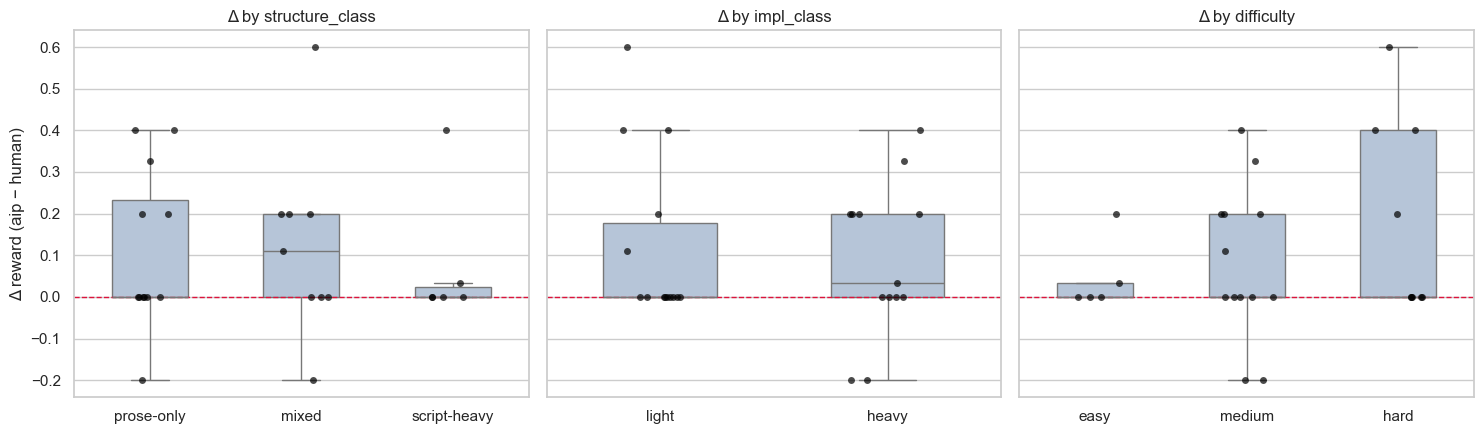

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
specs = [("structure_class", ["prose-only", "mixed", "script-heavy"]),
         ("impl_class",       ["light", "heavy"]),
         ("difficulty",       ["easy", "medium", "hard"])]
for ax, (col, order) in zip(axes, specs):
    sns.boxplot(data=df, x=col, y="delta", order=order, ax=ax,
                color="lightsteelblue", fliersize=0, width=0.5)
    sns.stripplot(data=df, x=col, y="delta", order=order, ax=ax,
                  color="black", size=5, jitter=0.18, alpha=0.7)
    ax.axhline(0, color="crimson", lw=1, ls="--")
    ax.set_title(f"Δ by {col}")
    ax.set_xlabel(""); ax.set_ylabel("Δ reward (aip − human)")
plt.tight_layout(); plt.show()

In [3]:
# group summaries for each axis
for col in ["structure_class", "impl_class", "difficulty"]:
    print(f"\n=== {col} ===")
    print(df.groupby(col)["delta"].agg(["mean", "median", "count"]).round(3))


=== structure_class ===
                  mean  median  count
structure_class                      
mixed            0.123    0.11      9
prose-only       0.111    0.00     12
script-heavy     0.072    0.00      6

=== impl_class ===
             mean  median  count
impl_class                      
heavy       0.089   0.033     13
light       0.122   0.000     14

=== difficulty ===
             mean  median  count
difficulty                      
easy        0.047     0.0      5
hard        0.178     0.0      9
medium      0.080     0.0     13


## 2. The headroom confound (read this before trusting any correlation)

Δ is bounded above by `1 − human_r`: if the human skill already scores 1.0, conversion **cannot**
show a positive Δ (only a regression). So Δ mechanically correlates with where the human happens to
be weak. Many of our ties are mutual ceilings (both 1.0) or mutual floors (both 0.0) where no
packaging could move the result. Plotting Δ against the human baseline shows how much of the signal
is headroom vs. genuine structural effect.

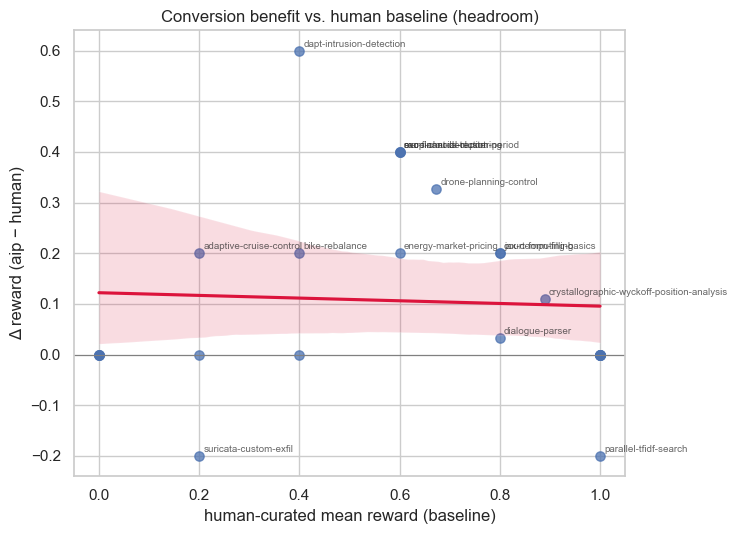

Spearman(delta, human_r): rho=-0.13  p=0.529
Tasks where both arms are at ceiling/floor (delta forced ~0): 11


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.regplot(data=df, x="human_r", y="delta", ax=ax,
            scatter_kws=dict(s=45, alpha=0.75), line_kws=dict(color="crimson"))
for _, r in df.iterrows():
    if abs(r.delta) > 1e-9:
        ax.annotate(r.task, (r.human_r, r.delta), fontsize=7, alpha=0.7,
                    xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="gray", lw=.8)
ax.set_xlabel("human-curated mean reward (baseline)")
ax.set_ylabel("Δ reward (aip − human)")
ax.set_title("Conversion benefit vs. human baseline (headroom)")
plt.tight_layout(); plt.show()

rho, p = spearmanr(df.human_r, df.delta)
print(f"Spearman(delta, human_r): rho={rho:+.2f}  p={p:.3f}")
print("Tasks where both arms are at ceiling/floor (delta forced ~0):",
      int(((df.human_r.isin([0,1])) & (df.aip_r.isin([0,1])) & (df.delta.abs()<1e-9)).sum()))

## 3. Spearman correlation heatmap — outcomes vs. continuous metrics

Rank correlation (robust to the skewed LoC/count metrics and small n). Rows = outcomes
(`human_r`, `aip_r`, `delta`); columns = structural metrics + the ordinal strata. Look at the
`delta` row: which metrics rank-track the conversion benefit?

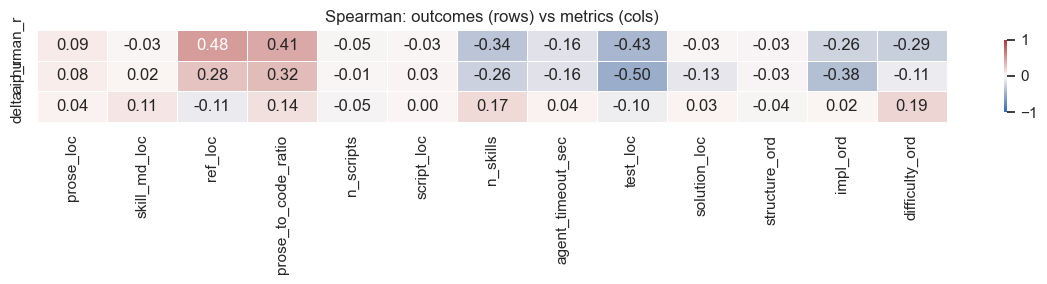

In [5]:
cont = ["prose_loc", "skill_md_loc", "ref_loc", "prose_to_code_ratio",
        "n_scripts", "script_loc", "n_skills",
        "agent_timeout_sec", "test_loc", "solution_loc",
        "structure_ord", "impl_ord", "difficulty_ord"]
outcomes = ["human_r", "aip_r", "delta"]
sub = df[outcomes + cont].apply(pd.to_numeric, errors="coerce")
corr = sub.corr(method="spearman").loc[outcomes, cont]

plt.figure(figsize=(12, 3.0))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            cbar_kws=dict(shrink=.8), linewidths=.5)
plt.title("Spearman: outcomes (rows) vs metrics (cols)")
plt.tight_layout(); plt.show()

In [6]:
# delta-vs-metric correlations with p-values, ranked
rows = []
for m in cont:
    s = df[["delta", m]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(s) > 3:
        rho, p = spearmanr(s["delta"], s[m])
        rows.append((m, len(s), round(rho, 3), round(p, 3)))
pd.DataFrame(rows, columns=["metric", "n", "rho_vs_delta", "p"]) \
  .sort_values("rho_vs_delta").reset_index(drop=True)

,metric,n,rho_vs_delta,p
0,ref_loc,27,-0.110,0.584
1,test_loc,27,-0.100,0.620
2,n_scripts,27,-0.049,0.808
3,structure_ord,27,-0.044,0.828
4,script_loc,27,0.000,1.000
5,impl_ord,27,0.020,0.920
6,solution_loc,27,0.034,0.867
7,agent_timeout_sec,27,0.042,0.837
8,prose_loc,27,0.043,0.832
9,skill_md_loc,27,0.114,0.571


## 4. Δ vs. key continuous metrics — scatter + regression

One panel per metric; red line = linear fit, title carries Spearman rho/p. Note
`prose_to_code_ratio` is **only defined for non-prose-only tasks** (script_loc > 0), so its panel
drops the prose-only group — exactly the high-upside tasks — interpret it carefully.

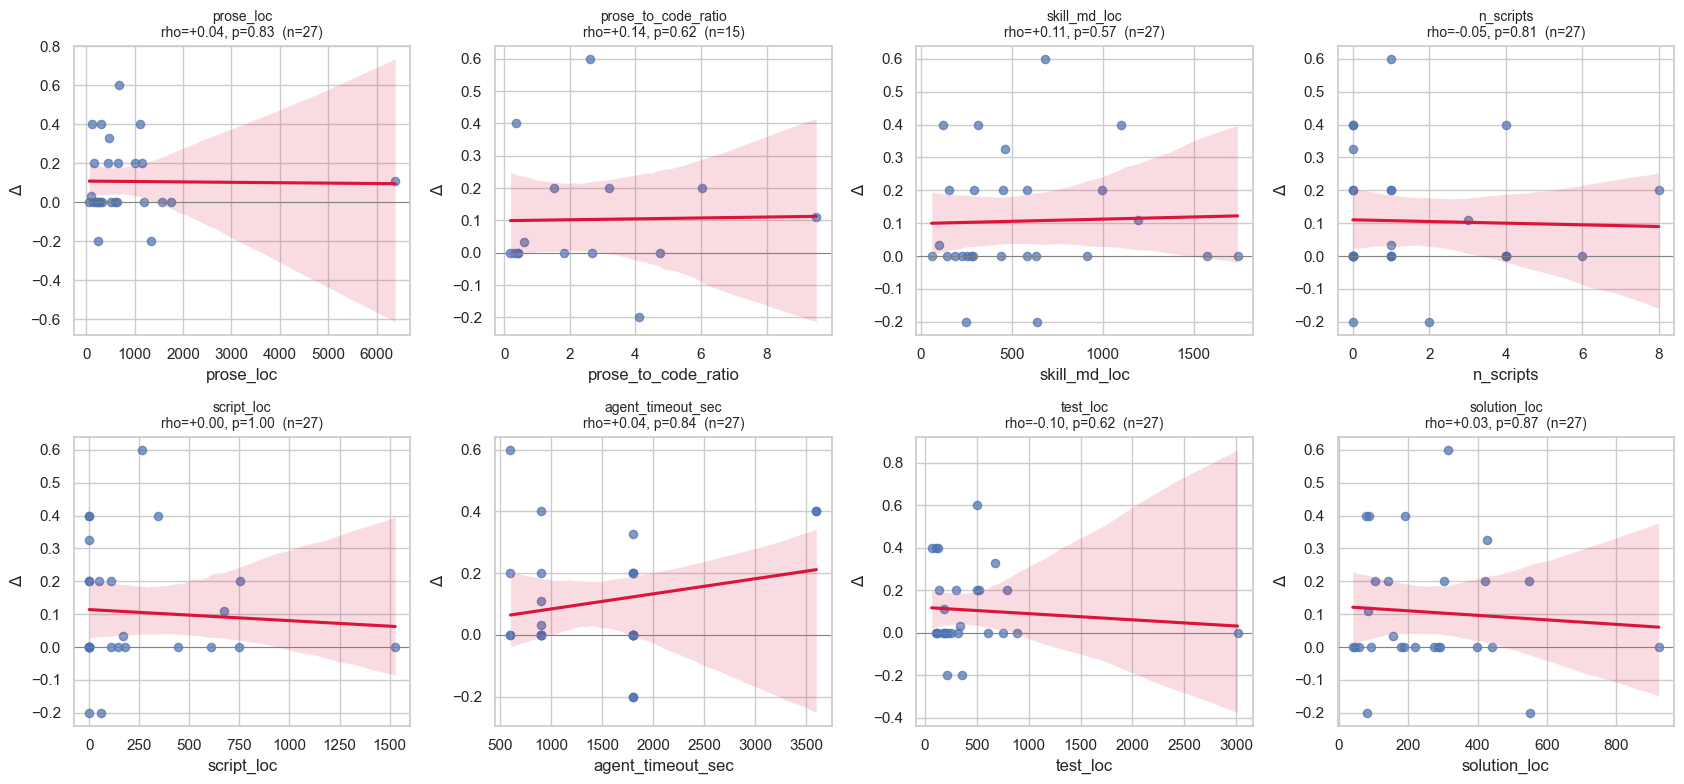

In [7]:
panel = ["prose_loc", "prose_to_code_ratio", "skill_md_loc", "n_scripts",
         "script_loc", "agent_timeout_sec", "test_loc", "solution_loc"]
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, m in zip(axes.ravel(), panel):
    s = df[["delta", m]].apply(pd.to_numeric, errors="coerce").dropna()
    sns.regplot(data=s, x=m, y="delta", ax=ax,
                scatter_kws=dict(s=35, alpha=0.7), line_kws=dict(color="crimson"))
    ax.axhline(0, color="gray", lw=.7)
    if len(s) > 3:
        rho, p = spearmanr(s["delta"], s[m])
        ax.set_title(f"{m}\nrho={rho:+.2f}, p={p:.2f}  (n={len(s)})", fontsize=10)
    ax.set_ylabel("Δ")
plt.tight_layout(); plt.show()

## Observations & caveats (starting notes — extend from here)

**What to read off the plots above**
- **Section 1** tests the original hypothesis directly: is the Δ distribution shifted up for
  `prose-only` and/or `heavy` impl? (Cohort C complicated this — several light-impl wins — so the
  pooled box plots are the cleanest test now.)
- **Section 2 is the load-bearing caveat.** If `delta` correlates strongly with `human_r`, much of
  any structural signal is really *headroom* (AIP can only lift tasks the human doesn't already
  ace). Consider restricting to `df.differentiated` or regressing Δ on a metric **while controlling
  for `human_r`** before claiming a structural driver.
- **Sections 3–4** surface candidate continuous drivers (prose_loc, ratio, script_loc, impl
  proxies). Treat low-n, high-p cells as noise.

**Caveats**
- n = 27 tasks, ~half ties; rank methods only; no multiple-comparison correction on the per-metric
  p-values.
- eval-3med (3 tasks) used **v0.3a2** packs and was a hand-picked medium set — consider a
  `spec == v0.3a3` filter (drop eval-3med) to check robustness.
- `prose_to_code_ratio` undefined for prose-only tasks (the high-upside group) — don't over-read it.

**Ideas to extend (for you to pick up)**
- Partial correlation / OLS: `delta ~ structure_ord + impl_ord + human_r` to separate structure
  from headroom.
- Split `delta` into *win magnitude* (where Δ>0) vs *regression risk* (where Δ<0) and profile each.
- Label each of the 12 wins by mechanism (executability vs. consistency lever) and color the
  scatters by it.
- Add wall-clock Δ as a second DV (AIP often wins on speed even when reward ties).

## Why the benefit is real even though no metric predicts it — the mechanism

The sections above establish two facts that seem in tension: **(1)** converting human skills to AIP
helps (12 wins / 2 losses / 13 ties, mean Δ +0.106), yet **(2)** no structural metric predicts
*which* tasks benefit. The resolution: the benefit isn't a property of the input document's shape —
it's about **moving error-prone work from run-time to author-time.**

**Mechanism — the conversion precommits the derivation.** A human prose skill *describes* a method;
at run time the solver must re-derive it (write the code, pick the commands, reconstruct the exact
procedure) fresh, every trial, under a clock. That re-derivation is the slow, high-variance,
error-prone step. AIP conversion performs it **once**, up front, with a stronger model, and bakes it
into runnable / structured nodes. At run time the agent stops deriving and starts executing.

**Evidence (from the per-task deep dives, not just the aggregate):**

1. **Behavior flips authoring → running.** On wins, human trials are Write-heavy (the agent writes
   the implementation) or stall in deliberation; AIP-cur trials are Terminal-heavy (run the shipped
   script, inspect, re-run). [drone, mars, dapt]
2. **Variance collapses** — the clearest tell. crystallographic: AIP 83 s ±1.5 vs human 138–255 s.
   dapt: AIP 5/5 at ~90 s vs human 2/5 scattered. Near-determinism is the signature of *executing a
   frozen artifact* rather than *reconstructing one* each trial.
3. **Failures fail deterministically too.** offer-letter (v0.3a2) went 0/5 — the same frozen-wrong
   conditional every trial; bike timed out repeatedly on a frozen over-engineered script. Freezing
   is the mechanism, and it cuts both ways.

**Why this is invisible to the correlations above.** The predictive quantity is *"how much must the
agent reconstruct at run time × did the frozen version get it right."* Neither factor is `prose_loc`
or `n_scripts`: mars has a *short* instruction but an enormous re-derivation burden (an 847-combo
grid search), while a long prose skill for a lookup task has almost none. Line/script counts measure
document size, not hidden derivation load — so they don't move with Δ.

**Honest hedge (format vs. author).** "Precommit the derivation" splits into two credits this eval
can't separate: the **format** (the graph + scripts make the derivation executable and freezable)
and the **author** (Opus doing the derivation well). Wins need both; losses are the author getting
it wrong inside a format that then faithfully froze the mistake. The control arm — the *same* scripts
shipped as plain markdown vs. as an AIP graph — is the experiment that would close this.

**One-line takeaway.** *AIP works by shifting method-derivation from the solver at run-time to the
author at compile-time, and freezing the result — which shows up as fewer wrong trials, lower
variance, and less wall-clock; it doesn't track input structure because derivation burden isn't a
surface feature of the document.*